# Crop Price Prediction — Modeling & Evaluation

This notebook trains and evaluates multiple regression models on the engineered feature dataset (`data/processed/features_dataset.csv`) using a **time-based split** (no shuffling) to avoid data leakage.

## Sections
1. Load Data
2. Time-Based Train/Test Split
3. Train Three Models
4. Evaluate All Models
5. Feature Importance
6. Prediction vs Actual Plot
7. Save Best Model

In [11]:
import json
import warnings
from datetime import date
from math import sqrt
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from tensorflow import keras
from tensorflow.keras import callbacks, layers

warnings.filterwarnings("ignore")

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Paths (notebook lives in notebooks/, project root is one level up)
DATASET_PATH = Path("../data/processed/features_dataset.csv")
FEATURE_COLUMNS_PATH = Path("../src/models/feature_columns.json")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../src/models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "price"

## Section 1 — Load Data

- Load `features_dataset.csv` (parse `date`)
- Load feature column names from `src/models/feature_columns.json`
- Print shape and feature columns list
- Print price statistics (mean, min, max, std)

In [12]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])

with open(FEATURE_COLUMNS_PATH, "r", encoding="utf-8") as f:
    feature_columns = json.load(f)

print("Dataset shape:", df.shape)
print("\nFeature columns (loaded from JSON):")
print(feature_columns)

price_stats = {
    "mean": float(df[TARGET_COLUMN].mean()),
    "min": float(df[TARGET_COLUMN].min()),
    "max": float(df[TARGET_COLUMN].max()),
    "std": float(df[TARGET_COLUMN].std()),
}
print("\nPrice statistics:")
print(price_stats)

display(df.head())

Dataset shape: (6353, 25)

Feature columns (loaded from JSON):
['commodity_encoded', 'market_encoded', 'admin1_encoded', 'pricetype_encoded', 'category_encoded', 'year', 'month', 'quarter', 'is_harvest_season', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'price_rolling_mean_3', 'price_rolling_std_3', 'price_rolling_mean_6']

Price statistics:
{'mean': 308.86736187627895, 'min': 54.02, 'max': 1645.58, 'std': 174.94159444781778}


,date,admin1,admin2,market,category,commodity,unit,pricetype,price,year,...,category_encoded,price_lag_1,price_lag_3,price_lag_6,price_lag_12,price_rolling_mean_3,price_rolling_std_3,price_rolling_mean_6,quarter,is_harvest_season
0,2016-11-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,228.31,2016,...,0,228.31,172.47,121.17,56.46,222.406667,10.224873,187.555000,4,1
1,2016-12-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,228.31,2016,...,0,228.31,210.60,113.17,53.66,228.310000,0.000000,206.745000,4,1
2,2017-01-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,248.85,2017,...,0,228.31,228.31,172.47,121.17,235.156667,11.858775,219.475000,1,1
3,2017-02-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,269.41,2017,...,0,248.85,228.31,172.47,121.17,248.856667,20.550001,235.631667,1,1
4,2021-06-15,Abia,Oboma Ngwa,Aba,cereals and tubers,"Cassava meal (gari, yellow)",KG,Retail,484.38,2021,...,0,269.41,228.31,210.60,121.17,334.213333,130.453820,281.261667,2,0


## Section 2 — Time-Based Train/Test Split

- Sort by date (ascending)
- Use the **last 20%** of rows as the test set (no shuffle)
- Split into X/y using the feature columns list
- Print train/test sizes and date ranges to confirm no leakage

In [13]:
df = df.sort_values("date", ascending=True).reset_index(drop=True)

n_total = len(df)
n_test = int(np.ceil(n_total * 0.2))
n_train = n_total - n_test

train_df = df.iloc[:n_train].copy()
test_df = df.iloc[n_train:].copy()

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET_COLUMN].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET_COLUMN].copy()

train_min_date = train_df["date"].min().date().isoformat()
train_max_date = train_df["date"].max().date().isoformat()
test_min_date = test_df["date"].min().date().isoformat()
test_max_date = test_df["date"].max().date().isoformat()

print(f"Total rows: {n_total}")
print(f"Train rows: {len(train_df)} | Date range: {train_min_date} to {train_max_date}")
print(f"Test rows : {len(test_df)} | Date range: {test_min_date} to {test_max_date}")

Total rows: 6353
Train rows: 5082 | Date range: 2003-01-15 to 2022-05-15
Test rows : 1271 | Date range: 2022-05-15 to 2023-01-15


## Section 3 — Train Three Models

Train:
- Linear Regression
- Decision Tree (`max_depth=10, random_state=42`)
- Random Forest (`n_estimators=100, random_state=42, n_jobs=-1`)

In [14]:
models = {}

print("Training Linear Regression...")
models["Linear Regression"] = LinearRegression()
models["Linear Regression"].fit(X_train, y_train)
lr_model = models["Linear Regression"]
print("Done.")

print("\nTraining Decision Tree...")
models["Decision Tree"] = DecisionTreeRegressor(max_depth=10, random_state=42)
models["Decision Tree"].fit(X_train, y_train)
dt_model = models["Decision Tree"]
print("Done.")

print("\nTraining Random Forest...")
models["Random Forest"] = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
models["Random Forest"].fit(X_train, y_train)
rf_model = models["Random Forest"]
print("Done.")

Training Linear Regression...
Done.

Training Decision Tree...
Done.

Training Random Forest...
Done.


### Model 4: Deep Neural Network (TensorFlow/Keras)

In [15]:
# Scale features for neural network
# Neural networks train better with scaled inputs
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for use in Flask app
scaler_path = MODELS_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")


# Build DNN architecture
def build_dnn(input_dim):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(64, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(32, activation="relu"),
            layers.Dense(1),  # regression output
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )
    return model


dnn_model = build_dnn(X_train_scaled.shape[1])
dnn_model.summary()

# Early stopping to prevent overfitting
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6
)

print("\nTraining Deep Neural Network...")
history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)
print("Done.")

Scaler saved to: ..\src\models\scaler.pkl


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 384 (1.50 KB)


Training Deep Neural Network...
Epoch 1/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 90346.6406 - mae: 265.8733 - val_loss: 110926.9844 - val_mae: 308.5974 - learning_rate: 0.0010
Epoch 2/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40071.5430 - mae: 179.7017 - val_loss: 10405.3564 - val_mae: 75.5125 - learning_rate: 0.0010
Epoch 3/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14149.4551 - mae: 97.9299 - val_loss: 5306.1802 - val_mae: 63.9015 - learning_rate: 0.0010
Epoch 4/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7573.6611 - mae: 67.6435 - val_loss: 1823.7264 - val_mae: 32.5083 - learning_rate: 0.0010
Epoch 5/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6284.9243 - mae: 60.6194 - val_loss: 1111.3212 - val_mae: 21.4818 - learning_rate: 0.0010
Epoch 6/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5979.0410 - mae: 58.3253 - val_loss: 1072.3458 - val_mae: 21.6977 - learning_rate: 0.0010
Epoch 7/200
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

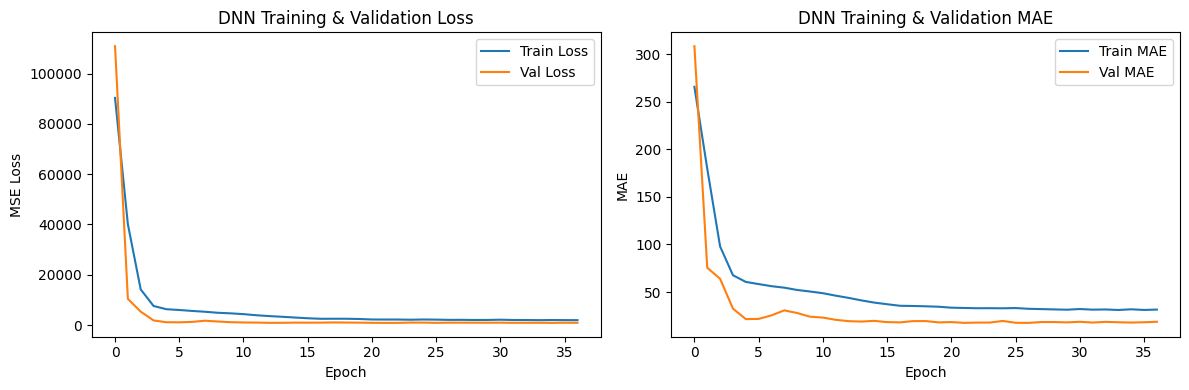

DNN training history plot saved to: ..\data\processed\plot7_dnn_training_history.png


In [16]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("DNN Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.title("DNN Training & Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plot_dnn_path = PROCESSED_DIR / "plot7_dnn_training_history.png"
plt.savefig(plot_dnn_path, bbox_inches="tight")
plt.show()
print(f"DNN training history plot saved to: {plot_dnn_path}")

## Section 4 — Evaluate All Models

Compute on `X_test, y_test`:
- MAE
- RMSE
- R²

Print a clean comparison table and the winner for each metric.

In [17]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3),
    }

# Evaluate DNN
dnn_preds = dnn_model.predict(X_test_scaled, verbose=0).flatten()
dnn_mae = mean_absolute_error(y_test, dnn_preds)
dnn_rmse = sqrt(mean_squared_error(y_test, dnn_preds))
dnn_r2 = r2_score(y_test, dnn_preds)

# Add to results dict alongside other models
results["Deep Neural Network"] = {
    "MAE": round(dnn_mae, 2),
    "RMSE": round(dnn_rmse, 2),
    "R2": round(dnn_r2, 3),
}

print("\nModel Comparison:")
print(f"{'Model':<25} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
print("-" * 58)
for name, metrics in results.items():
    print(
        f"{name:<25} | {metrics['MAE']:>8.2f} | "
        f"{metrics['RMSE']:>8.2f} | {metrics['R2']:>8.3f}"
    )


print("\nBest model by RMSE:", min(results, key=lambda x: results[x]["RMSE"]))

best_model_name = min(results, key=lambda x: results[x]["RMSE"])
best_model = models.get(best_model_name)
print("\nBest model selected by RMSE:", best_model_name)


Model Comparison:
Model                     |      MAE |     RMSE |       R²
----------------------------------------------------------
Linear Regression         |    17.03 |    29.31 |    0.980
Decision Tree             |    23.60 |    57.42 |    0.921
Random Forest             |    16.96 |    33.92 |    0.973
Deep Neural Network       |    18.83 |    28.48 |    0.981

Best model by RMSE: Deep Neural Network

Best model selected by RMSE: Deep Neural Network


## Section 5 — Feature Importance

Compute and plot Random Forest feature importances and save to `data/processed/plot5_feature_importance.png`.

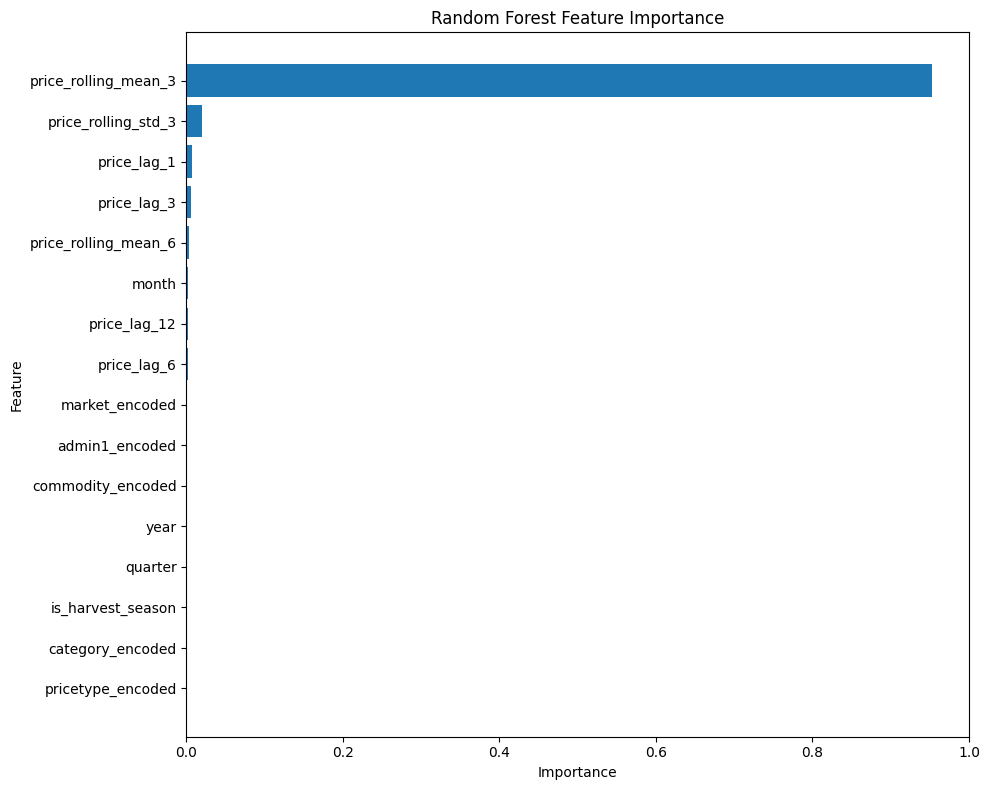

Feature importance plot saved to: ..\data\processed\plot5_feature_importance.png


In [18]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

fi = pd.DataFrame({"feature": feature_columns, "importance": importances}).sort_values(
    "importance", ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(fi["feature"], fi["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plot5_path = PROCESSED_DIR / "plot5_feature_importance.png"
plt.savefig(plot5_path, bbox_inches="tight")
plt.show()

print(f"Feature importance plot saved to: {plot5_path}")

Computing permutation importance for DNN...
(This uses the scaled test set)


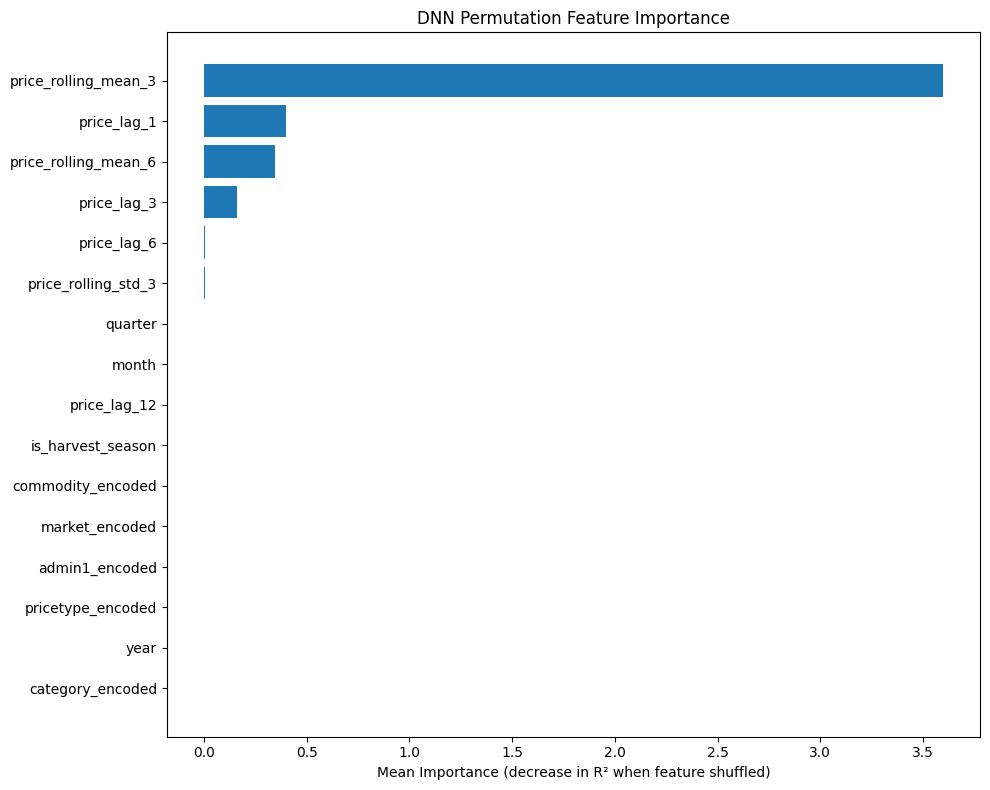

Saved to: ..\data\processed\plot8_dnn_feature_importance.png


In [19]:
# DNN does not have built-in feature importance
# Use permutation importance instead
from sklearn.inspection import permutation_importance

print("Computing permutation importance for DNN...")
print("(This uses the scaled test set)")


# Wrap DNN predict for sklearn compatibility
class DNNWrapper:
    def __init__(self, model, scaler):
        self.model = model
        self.scaler = scaler

    def fit(self, X, y):
        # Required by sklearn API — DNN already trained
        return self

    def predict(self, X):
        return self.model.predict(X, verbose=0).flatten()

    def score(self, X, y):
        # Required for permutation_importance scoring
        from sklearn.metrics import r2_score
        return r2_score(y, self.predict(X))


dnn_wrapper = DNNWrapper(dnn_model, scaler)

perm_result = permutation_importance(
    dnn_wrapper, X_test_scaled, y_test, n_repeats=10, random_state=42
)

# Plot DNN feature importance
feature_names = feature_columns
sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 8))
plt.barh(
    [feature_names[i] for i in sorted_idx],
    perm_result.importances_mean[sorted_idx],
)
plt.title("DNN Permutation Feature Importance")
plt.xlabel("Mean Importance (decrease in R² when feature shuffled)")
plt.tight_layout()
plot_dnn_imp_path = PROCESSED_DIR / "plot8_dnn_feature_importance.png"
plt.savefig(plot_dnn_imp_path, bbox_inches="tight")
plt.show()
print(f"Saved to: {plot_dnn_imp_path}")

## Section 6 — Prediction vs Actual Plot

Use the best model (by RMSE) to generate predictions on the test set, and save the plot to `data/processed/plot6_predicted_vs_actual.png`.

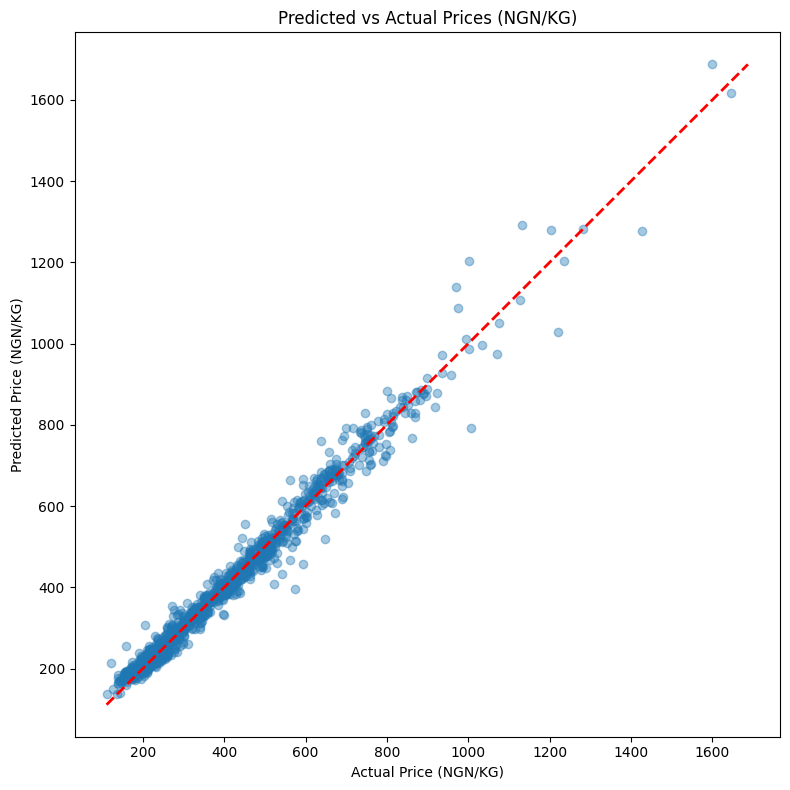

Predicted vs Actual plot saved to: ..\data\processed\plot6_predicted_vs_actual.png


In [20]:
if best_model_name == "Deep Neural Network":
    y_pred_best = dnn_model.predict(X_test_scaled, verbose=0).flatten()
else:
    y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4)

min_val = float(min(y_test.min(), y_pred_best.min()))
max_val = float(max(y_test.max(), y_pred_best.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.title("Predicted vs Actual Prices (NGN/KG)")
plt.xlabel("Actual Price (NGN/KG)")
plt.ylabel("Predicted Price (NGN/KG)")
plt.tight_layout()

plot6_path = PROCESSED_DIR / "plot6_predicted_vs_actual.png"
plt.savefig(plot6_path, bbox_inches="tight")
plt.show()

print(f"Predicted vs Actual plot saved to: {plot6_path}")

## Section 7 — Save Best Model

- Select best model by lowest RMSE
- Save to `src/models/best_model.joblib`
- Save metadata to `src/models/model_metadata.json`
- Print confirmation messages

In [21]:
# Always save DNN model in keras format
dnn_save_path = MODELS_DIR / "dnn_model.keras"
dnn_model.save(dnn_save_path)
print(f"DNN model saved to: {dnn_save_path}")

# Determine best model by RMSE
best_name = min(results, key=lambda x: results[x]["RMSE"])
print(f"\nBest model by RMSE: {best_name}")

# Save best sklearn model (Linear Regression, Decision Tree, or Random Forest)
sklearn_models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

best_model_path = MODELS_DIR / "best_model.joblib"
if best_name in sklearn_models:
    best_model = sklearn_models[best_name]
    joblib.dump(best_model, best_model_path)
    print(f"Best sklearn model saved: {best_name}")
else:
    # DNN won - but keep best sklearn as fallback for Flask
    best_sklearn = min(sklearn_models, key=lambda x: results[x]["RMSE"])
    joblib.dump(sklearn_models[best_sklearn], best_model_path)
    print(f"DNN won overall. Flask fallback: {best_sklearn}")

# Update metadata with all 4 model results (model_name kept for Flask app)
metadata = {
    "best_model_name": best_name,
    "model_name": best_name,
    "all_results": results,
    "mae": float(results[best_name]["MAE"]),
    "rmse": float(results[best_name]["RMSE"]),
    "r2": float(results[best_name]["R2"]),
    "train_size": len(X_train),
    "test_size": len(X_test),
    "train_date_range": [train_min_date, train_max_date],
    "test_date_range": [test_min_date, test_max_date],
    "feature_columns": feature_columns,
    "trained_on": str(date.today()),
    "dnn_model_path": "src/models/dnn_model.keras",
    "scaler_path": "src/models/scaler.pkl",
}

metadata_path = MODELS_DIR / "model_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("Metadata updated with all 4 model results")
print("Saved sklearn model path:", best_model_path)
print("Saved metadata to:", metadata_path)
print("\nMetadata summary:")
print(metadata)

DNN model saved to: ..\src\models\dnn_model.keras

Best model by RMSE: Deep Neural Network
DNN won overall. Flask fallback: Linear Regression
Metadata updated with all 4 model results
Saved sklearn model path: ..\src\models\best_model.joblib
Saved metadata to: ..\src\models\model_metadata.json

Metadata summary:
{'best_model_name': 'Deep Neural Network', 'model_name': 'Deep Neural Network', 'all_results': {'Linear Regression': {'MAE': 17.03, 'RMSE': 29.31, 'R2': 0.98}, 'Decision Tree': {'MAE': 23.6, 'RMSE': 57.42, 'R2': 0.921}, 'Random Forest': {'MAE': 16.96, 'RMSE': 33.92, 'R2': 0.973}, 'Deep Neural Network': {'MAE': 18.83, 'RMSE': 28.48, 'R2': 0.981}}, 'mae': 18.83, 'rmse': 28.48, 'r2': 0.981, 'train_size': 5082, 'test_size': 1271, 'train_date_range': ['2003-01-15', '2022-05-15'], 'test_date_range': ['2022-05-15', '2023-01-15'], 'feature_columns': ['commodity_encoded', 'market_encoded', 'admin1_encoded', 'pricetype_encoded', 'category_encoded', 'year', 'month', 'quarter', 'is_harvest

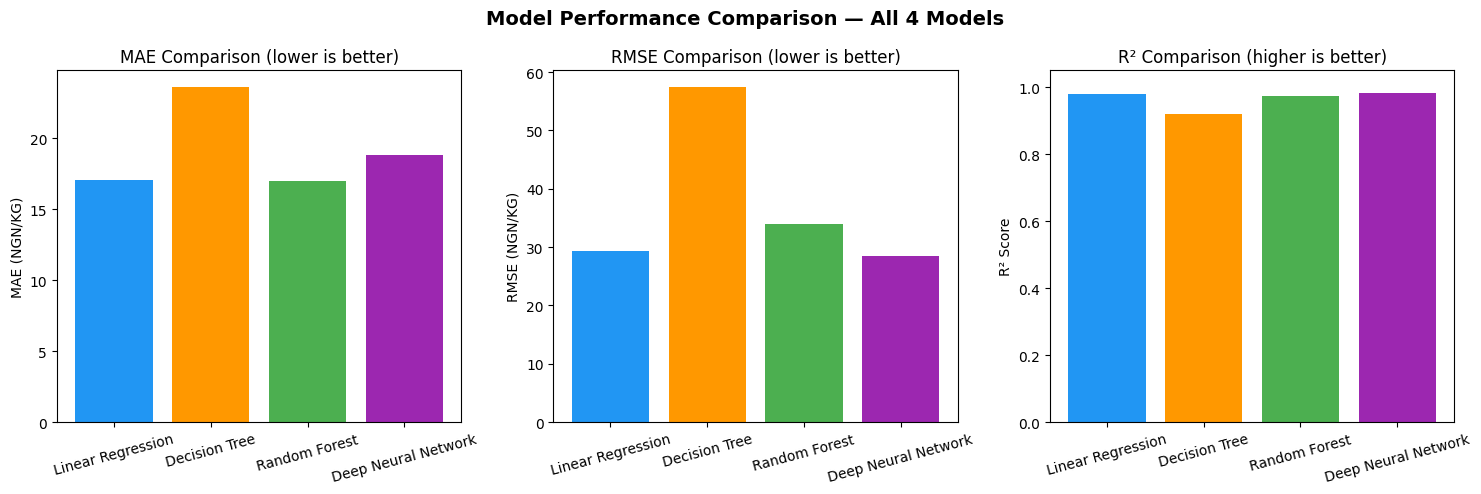

Comparison plot saved to: ..\data\processed\plot9_all_models_comparison.png


In [22]:
# Plot all 4 models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = list(results.keys())
mae_vals = [results[m]["MAE"] for m in model_names]
rmse_vals = [results[m]["RMSE"] for m in model_names]
r2_vals = [results[m]["R2"] for m in model_names]

colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

axes[0].bar(model_names, mae_vals, color=colors)
axes[0].set_title("MAE Comparison (lower is better)")
axes[0].set_ylabel("MAE (NGN/KG)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(model_names, rmse_vals, color=colors)
axes[1].set_title("RMSE Comparison (lower is better)")
axes[1].set_ylabel("RMSE (NGN/KG)")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(model_names, r2_vals, color=colors)
axes[2].set_title("R² Comparison (higher is better)")
axes[2].set_ylabel("R² Score")
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle(
    "Model Performance Comparison — All 4 Models", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plot_comp_path = PROCESSED_DIR / "plot9_all_models_comparison.png"
plt.savefig(plot_comp_path, bbox_inches="tight")
plt.show()
print(f"Comparison plot saved to: {plot_comp_path}")